# 01. Data Extraction: Market Data (OHLCV)


## Objective
To fetch granular historical market data for **Tata Motors** and its key peers (**Maruti Suzuki**, **Mahindra & Mahindra**) along with the benchmark index (**NIFTY 50**).


## Scope
- **Timeline:** Jan 1, 2018 to Present (Covering Pre-Covid, Covid, Post-Covid, and Oct 2024 Crash).
- **Data Source:** Yahoo Finance (`yfinance` API).
- **Granularity:** Daily (1 Day).


In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configure Plotting
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)


## 2. Configuration


Defining the tickers and date range. We use `.NS` suffix for NSE stocks.


In [2]:
TICKERS = {
    'TATA_MOTORS': 'TATAMOTORS.NS',
    'MARUTI': 'MARUTI.NS',
    'M_AND_M': 'M&M.NS',
    'NIFTY_50': '^NSEI'
}


In [3]:
START_DATE = '2018-01-01'
END_DATE = pd.Timestamp.today().strftime('%Y-%m-%d')
print(f"Fetching data from {START_DATE} to {END_DATE}")


Fetching data from 2018-01-01 to 2026-02-11


## 3. Tata Motors (Target Variable)


Fetching the primary stock data.


In [4]:
tata_df = yf.download(TICKERS['TATA_MOTORS'], start=START_DATE, end=END_DATE, progress=False)


C:\Users\tuhin\AppData\Local\Temp\ipykernel_19264\447999921.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tata_df = yf.download(TICKERS['TATA_MOTORS'], start=START_DATE, end=END_DATE, progress=False)

1 Failed download:
['TATAMOTORS.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-01-01 -> 2026-02-11) (Yahoo error = "No data found, symbol may be delisted")')


In [5]:
# Check shape
print(f"Data Shape: {tata_df.shape}")


Data Shape: (0, 6)


In [6]:
tata_df.head()


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TATAMOTORS.NS,TATAMOTORS.NS,TATAMOTORS.NS,TATAMOTORS.NS,TATAMOTORS.NS,TATAMOTORS.NS
Date,,,,,,


In [7]:
tata_df.tail()


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TATAMOTORS.NS,TATAMOTORS.NS,TATAMOTORS.NS,TATAMOTORS.NS,TATAMOTORS.NS,TATAMOTORS.NS
Date,,,,,,


### 3.1 Data Validation: Tata Motors


Checking for missing values (NaNs).


In [8]:
tata_df.isnull().sum()


Price      Ticker       
Adj Close  TATAMOTORS.NS    0
Close      TATAMOTORS.NS    0
High       TATAMOTORS.NS    0
Low        TATAMOTORS.NS    0
Open       TATAMOTORS.NS    0
Volume     TATAMOTORS.NS    0
dtype: int64

Checking for duplicate indices.


In [9]:
tata_df.index.duplicated().sum()


np.int64(0)

### 3.2 Visual Inspection: Tata Motors


Plotting the Adjusted Close price to verify the data integrity, especially around the Covid crash (2020) and the recent Oct 2024 drop.


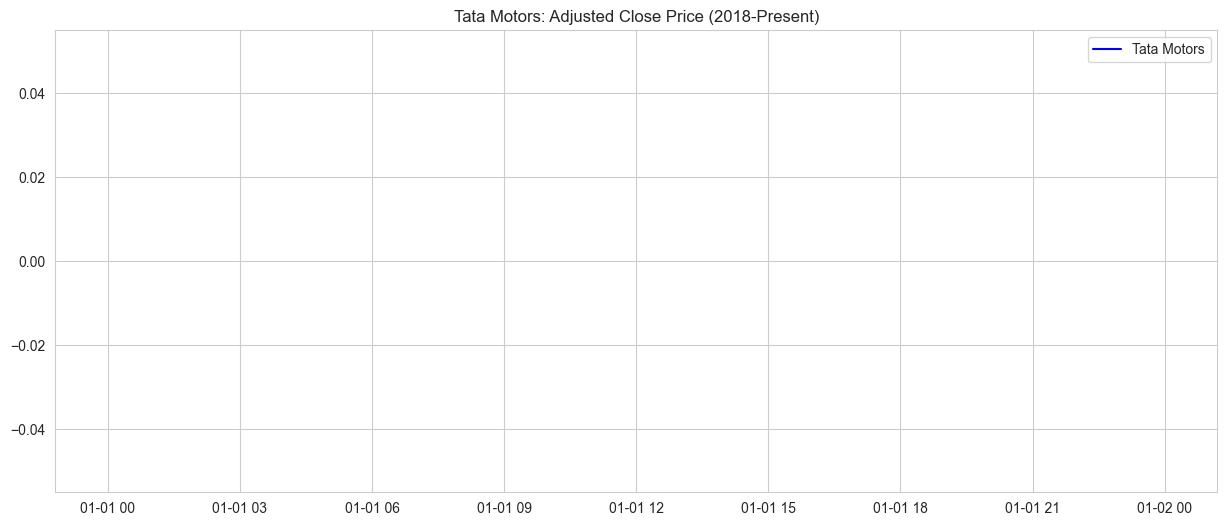

In [10]:
plt.figure(figsize=(15, 6))
plt.plot(tata_df['Adj Close'], label='Tata Motors', color='blue')
plt.title('Tata Motors: Adjusted Close Price (2018-Present)')
plt.legend()
plt.show()


In [11]:
# Zooming in on Oct 2024 (Ratan Tata's Passing)
subset_oct_2024 = tata_df['2024-10-01':'2024-10-31']
plt.figure(figsize=(15, 6))
plt.plot(subset_oct_2024['Adj Close'], marker='o', color='red')
plt.title('Tata Motors: Oct 2024 Price Action')
plt.grid(True)
plt.show()


KeyError: 'Adj Close'

<Figure size 1500x600 with 0 Axes>

## 4. Peer 1: Maruti Suzuki


Comparison is crucial (Relative Strength). Fetching Maruti data.


In [ ]:
maruti_df = yf.download(TICKERS['MARUTI'], start=START_DATE, end=END_DATE, progress=False)


In [ ]:
maruti_df.head()


### 4.1 Validation: Maruti


In [ ]:
maruti_df.isnull().sum()


### 4.2 Visualization: Maruti


In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(maruti_df['Adj Close'], label='Maruti', color='green')
plt.title('Maruti Suzuki: Adjusted Close Price')
plt.legend()
plt.show()


## 5. Peer 2: Mahindra & Mahindra


In [ ]:
mm_df = yf.download(TICKERS['M_AND_M'], start=START_DATE, end=END_DATE, progress=False)


In [ ]:
mm_df.head()


### 5.1 Validation: M&M


In [ ]:
mm_df.isnull().sum()


### 5.2 Visualization: M&M


In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(mm_df['Adj Close'], label='M&M', color='#8B4513')
plt.title('Mahindra & Mahindra: Adjusted Close Price')
plt.legend()
plt.show()


## 6. Benchmark: NIFTY 50


To calculate Beta and Relative Strength, we need the market index.


In [ ]:
nifty_df = yf.download(TICKERS['NIFTY_50'], start=START_DATE, end=END_DATE, progress=False)


In [ ]:
nifty_df.head()


### 6.1 Validation: Nifty 50


In [ ]:
nifty_df.isnull().sum()


### 6.2 Visualization: Nifty 50


In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(nifty_df['Adj Close'], label='Nifty 50', color='black')
plt.title('NIFTY 50 Index: Adjusted Close Price')
plt.legend()
plt.show()


## 7. Data Standardization


YFinance often returns Multi-Index columns if multiple tickers are fetched, or even specifically formatted single tickers. We ensure flat, clean column names.


In [ ]:
def flatten_columns(df, ticker_name):
    # If columns are MultiIndex, drop the level
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)
    
    # Add ticker prefix to avoid confusion later
    # Actually, for raw storage, we keep standard OHLCV and verify later.
    # Let's just ensure they are 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'
    return df


In [ ]:
tata_df = flatten_columns(tata_df, 'TATA')
maruti_df = flatten_columns(maruti_df, 'MARUTI')
mm_df = flatten_columns(mm_df, 'MM')
nifty_df = flatten_columns(nifty_df, 'NIFTY')


## 8. Export Raw Data


Saving these datasets to `.csv` for the next stage (Cleaning & Preprocessing). We create a specific `raw_data` folder.


In [ ]:
RAW_DIR = '../data/raw_market_data'
os.makedirs(RAW_DIR, exist_ok=True)


In [ ]:
tata_path = os.path.join(RAW_DIR, 'tata_motors_raw.csv')
tata_df.to_csv(tata_path)
print(f"Saved: {tata_path}")


In [ ]:
maruti_path = os.path.join(RAW_DIR, 'maruti_raw.csv')
maruti_df.to_csv(maruti_path)
print(f"Saved: {maruti_path}")


In [ ]:
mm_path = os.path.join(RAW_DIR, 'mm_raw.csv')
mm_df.to_csv(mm_path)
print(f"Saved: {mm_path}")


In [ ]:
nifty_path = os.path.join(RAW_DIR, 'nifty_raw.csv')
nifty_df.to_csv(nifty_path)
print(f"Saved: {nifty_path}")


## 9. Conclusion


We have successfully extracted granular daily data for our 3 stocks and 1 index. Visual checks confirm data availability for the 2018-2024 period.


**Next Step:** `02_Data_Extraction_News.ipynb` to scrape historical news headlines.
